In [39]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize']=(12,5)

import yfinance as yf
import pandas_datareader as pdr
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import signal,stats
from scipy .stats import kstest, ks_2samp

from statsmodels.tsa.seasonal import seasonal_decompose,STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR, VARMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

**Open**: The price of the stock at the moment the market opened (9:30 AM EST).

**High**: The highest price anyone was willing to pay for the stock during that specific day.

**Low**: The lowest price the stock dropped to during that trading day.

**Close**: The final price of the stock when the market closed (4:00 PM EST).

**Volume**: The total number of shares bought and sold during that day.

**Dividend**: A portion of company earnings paid out in cash to shareholders.

**Stock Split**: Divides existing shares into multiple units, lowering the individual share price to boost stock liquidity while keeping total market value the same.

Adjusted Close = Dividends + Splits

**Adjusted Close**: Stock's closing price that is changed to show its true value by accounting for dividends, stock splits, and rights offerings.

**NOTE**
- Use adjusted close for long-term analysis, historical performance tracking, and strategy backtesting.
- Use the raw close price when placing live trades or analyzing short-term, real-time market action.

In [3]:
# The ticker for Jio Financial Services on the National Stock Exchange (NSE)
ticker_symbol = "RELIANCE.NS"

# Create a ticker object
jio_stock = yf.Ticker(ticker_symbol)

# Fetch historical market data
df = jio_stock.history(start='2025-01-01')   #weak stationary data
df.head(5)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-01 00:00:00+05:30,1204.448352,1215.800389,1201.226179,1210.793579,5892590,0.0,0.0
2025-01-02 00:00:00+05:30,1210.793626,1233.794938,1209.554328,1231.167725,15486276,0.0,0.0
2025-01-03 00:00:00+05:30,1233.249818,1251.244443,1224.921714,1240.437744,15521102,0.0,0.0
2025-01-06 00:00:00+05:30,1243.213557,1251.194681,1204.597097,1207.571411,14816766,0.0,0.0
2025-01-07 00:00:00+05:30,1211.537128,1233.844481,1210.793549,1230.225708,10070505,0.0,0.0


In [4]:
#extracting the date only from the datetime column
df.index = (df.index).strftime('%Y-%m-%d')

In [5]:
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-01,1204.448352,1215.800389,1201.226179,1210.793579,5892590,0.0,0.0
2025-01-02,1210.793626,1233.794938,1209.554328,1231.167725,15486276,0.0,0.0
2025-01-03,1233.249818,1251.244443,1224.921714,1240.437744,15521102,0.0,0.0
2025-01-06,1243.213557,1251.194681,1204.597097,1207.571411,14816766,0.0,0.0
2025-01-07,1211.537128,1233.844481,1210.793549,1230.225708,10070505,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 435 entries, 2025-01-01 to 2026-09-25
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          435 non-null    float64
 1   High          435 non-null    float64
 2   Low           435 non-null    float64
 3   Close         435 non-null    float64
 4   Volume        435 non-null    int64  
 5   Dividends     435 non-null    float64
 6   Stock Splits  435 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 27.2+ KB


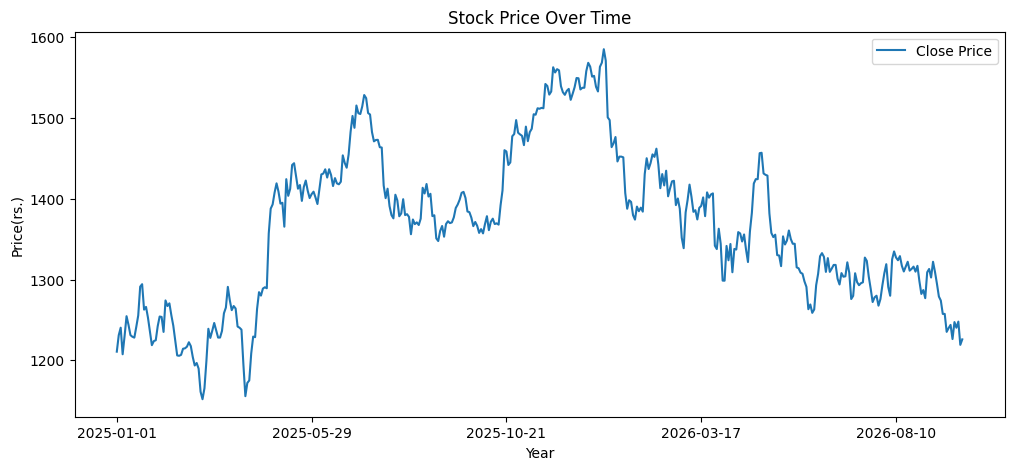

In [7]:
#line chart showing the price trend over time
df['Close'].plot(label='Close Price')
plt.title('Stock Price Over Time')
plt.xlabel('Year')
plt.ylabel('Price(rs.)')
plt.legend()
plt.show()

In [8]:
prices = df['Close']

## Classical Decomposition

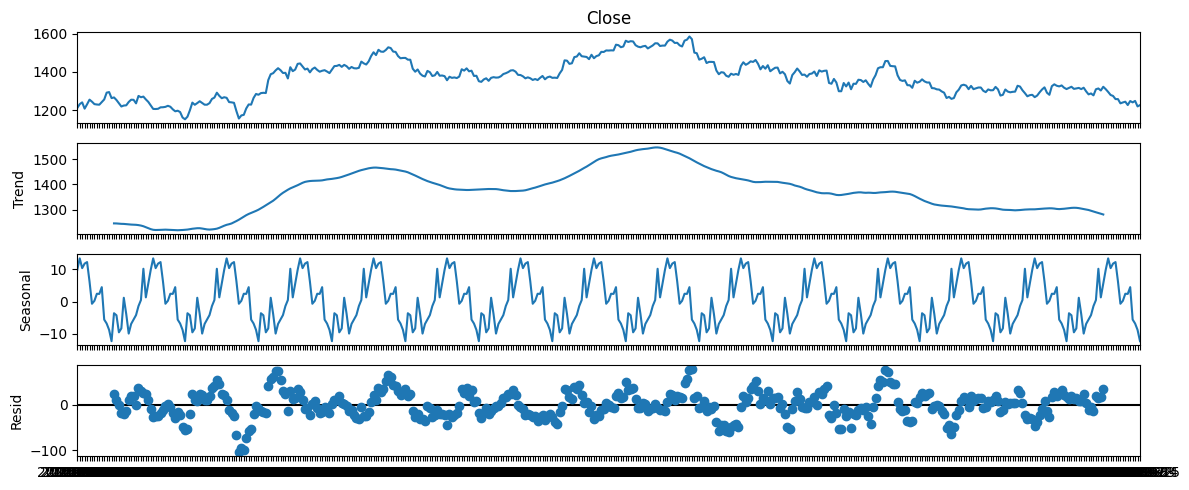

In [9]:
#additive model
result = seasonal_decompose(prices,model='additive',period=30)
result.plot()
plt.show()

## STL Decomposition

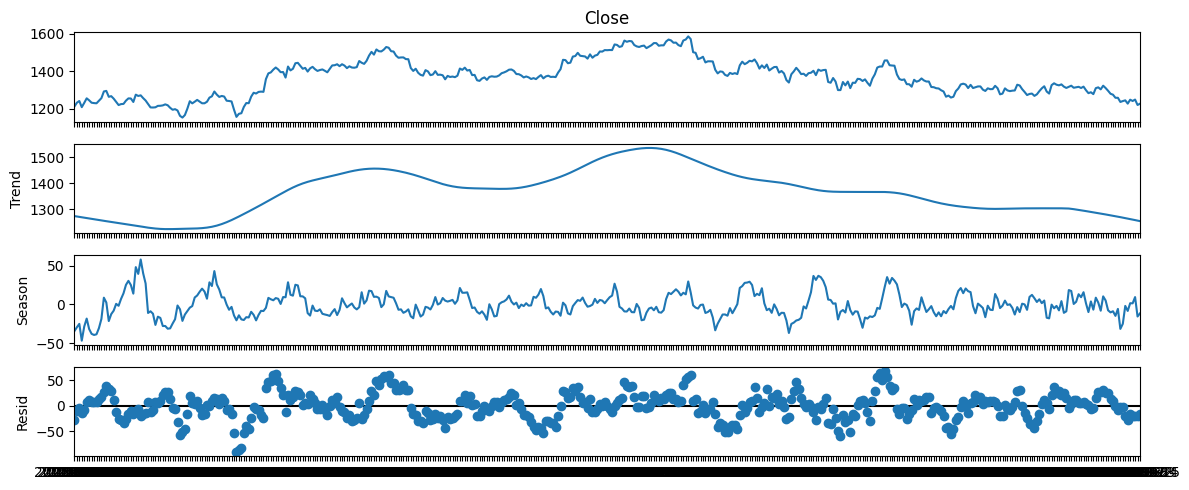

In [10]:
stl = STL(prices,period=30)
result_stl = stl.fit()
result_stl.plot()
plt.show()

## Stationary Data

In [11]:
# ADF Test
def adf_test(prices):

    prices = prices.dropna()

    result_adf = adfuller(prices)

    print("ADF Statistic:", result_adf[0])

    p_value = result_adf[1]
    print("p-value:", p_value)

    if p_value < 0.05:
        print("\nEvidence suggests the series is stationary")
    else:
        print("\nEvidence suggests the series is non-stationary")

adf_test(prices)

ADF Statistic: -1.9860740890652957
p-value: 0.29271230799511694

Evidence suggests the series is non-stationary


In [12]:
#KPSS Test
def kpss_test(prices):

    prices = prices.dropna()

    result_kpss = kpss(
        prices,
        regression='c',
        nlags='auto'
    )

    kpss_statistic = result_kpss[0]
    p_value = result_kpss[1]

    print("KPSS Statistic:", kpss_statistic)
    print("p-value:", p_value)

    if p_value < 0.05:
        print("\nEvidence suggests the series is non-stationary")
    else:
        print("\nEvidence suggests the series is stationary")

    return p_value

kpss_test(prices)

KPSS Statistic: 0.6555259623505595
p-value: 0.017588548877221864

Evidence suggests the series is non-stationary


np.float64(0.017588548877221864)

## Non-Stationary Data to Stationary Data

In [13]:
# Differencing
prices_diff = prices.diff()  #first order differencing
prices_diff


,Close
Date,
2025-01-01,NaN
2025-01-02,20.374146
2025-01-03,9.270020
2025-01-06,-32.866333
2025-01-07,22.654297
...,...
2026-09-21,21.000000
2026-09-22,-7.000000
2026-09-23,7.599976


In [14]:
prices_diff.diff()  #second order differencing

,Close
Date,
2025-01-01,NaN
2025-01-02,NaN
2025-01-03,-11.104126
2025-01-06,-42.136353
2025-01-07,55.520630
...,...
2026-09-21,38.500000
2026-09-22,-28.000000
2026-09-23,14.599976


In [15]:
#log transformation
prices_log = np.log(prices)

#square root transformation
prices_sqrt = np.sqrt(prices)

#box-cox transformation (we only use positive values)
prices_boxcox, lmbda = stats.boxcox(prices[prices>0])

print('prices_log:\n',prices_log.head(),'\n','***'*10)
print('prices_sqrt:\n',prices_sqrt.head(),'\n','***'*10)
print('prices_boxcox:\n',prices_boxcox)

prices_log:
 Date
2025-01-01    7.099031
2025-01-02    7.115718
2025-01-03    7.123220
2025-01-06    7.096367
2025-01-07    7.114953
Name: Close, dtype: float64 
 ******************************
prices_sqrt:
 Date
2025-01-01    34.796459
2025-01-02    35.088000
2025-01-03    35.219849
2025-01-06    34.750128
2025-01-07    35.074574
Name: Close, dtype: float64 
 ******************************
prices_boxcox:
 [7.89147264 7.91202392 7.92126549 7.88819175 7.91108102 7.93531929
 7.92480565 7.9121231  7.910088   7.90899466 7.92229888 7.93624413
 7.97071206 7.97364503 7.94328075 7.94656724 7.93351611 7.91648018
 7.89961289 7.90466188 7.90575883 7.92313518 7.93492961 7.93444238
 7.91608468 7.9543628  7.94762871 7.950856   7.93648748 7.92372504
 7.9051107  7.88672531 7.88626982 7.88743346 7.89514727 7.89564995
 7.8977082  7.90326406 7.89841025 7.88469969 7.87396082 7.87712578
 7.86996791 7.84003306 7.8301778  7.84459227 7.87967245 7.91993525
 7.90864654 7.91746821 7.92706247 7.91806084 7.9090939

In [16]:
adf_test(prices_diff)
print("*"*50)
adf_test(prices_sqrt)


ADF Statistic: -20.28477253968322
p-value: 0.0

Evidence suggests the series is stationary
**************************************************
ADF Statistic: -1.9987247263137506
p-value: 0.28713254203805455

Evidence suggests the series is non-stationary


In [17]:
#using linear trend
trend = np.polyfit(np.arange(len(prices)),prices,1)
trend_line = np.polyval(trend,np.arange(len(prices)))
prices_detrended = prices - trend_line

adf_test(prices_detrended)

ADF Statistic: -1.8704825056576553
p-value: 0.3460718966320836

Evidence suggests the series is non-stationary


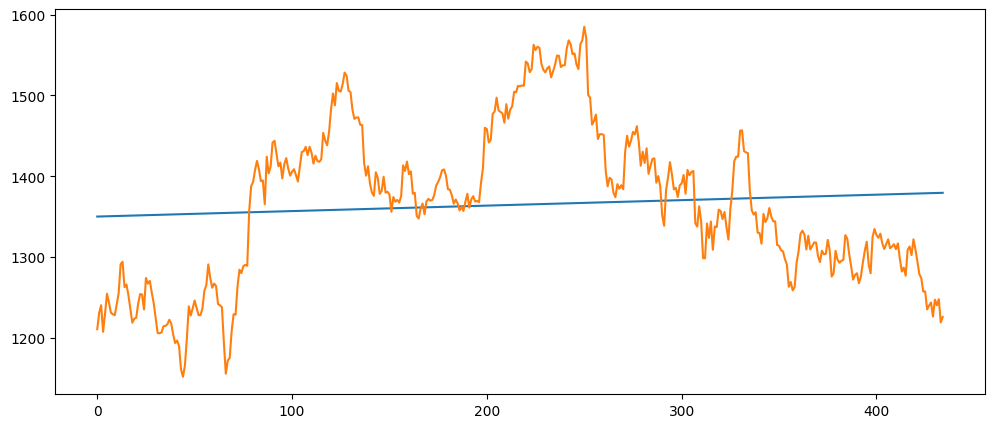

In [18]:
plt.plot(np.arange(len(prices)),trend_line)
plt.plot(np.arange(len(prices)),prices)
plt.show()

In [19]:
# using moving avg to remove trend
window = 10
prices_ma = prices.rolling(window=window).mean()
prices_detrended = prices - prices_ma
prices_detrended = prices_detrended.dropna()

adf_test(prices_detrended)

ADF Statistic: -7.18352477202897
p-value: 2.612399694033102e-10

Evidence suggests the series is stationary


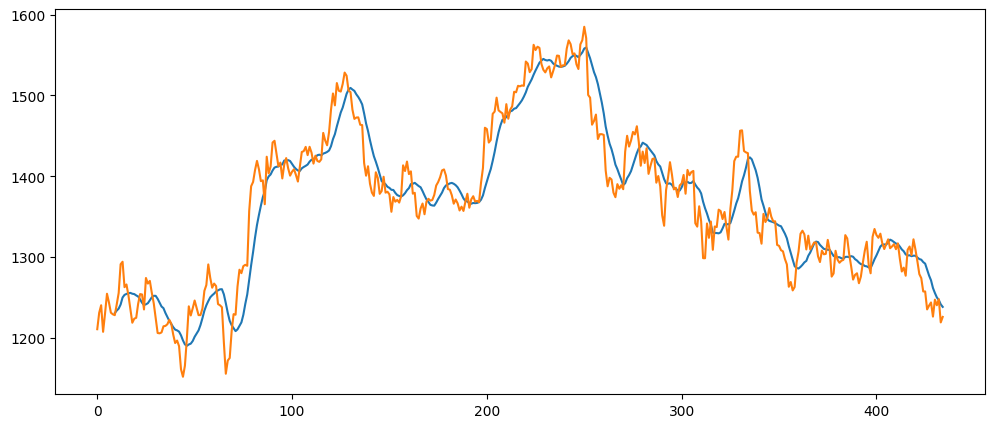

In [20]:
plt.plot(np.arange(len(prices)),prices_ma)
plt.plot(np.arange(len(prices)),prices)
plt.show()

In [21]:
# seasonal decomposeition using moving averages
decomposition = seasonal_decompose(prices,model='additive',period=30)
prices_adjusted = prices/decomposition.seasonal
prices_adjusted = prices_adjusted.dropna()

adf_test(prices_adjusted)

ADF Statistic: -6.569883717325969
p-value: 7.985265144735701e-09

Evidence suggests the series is stationary


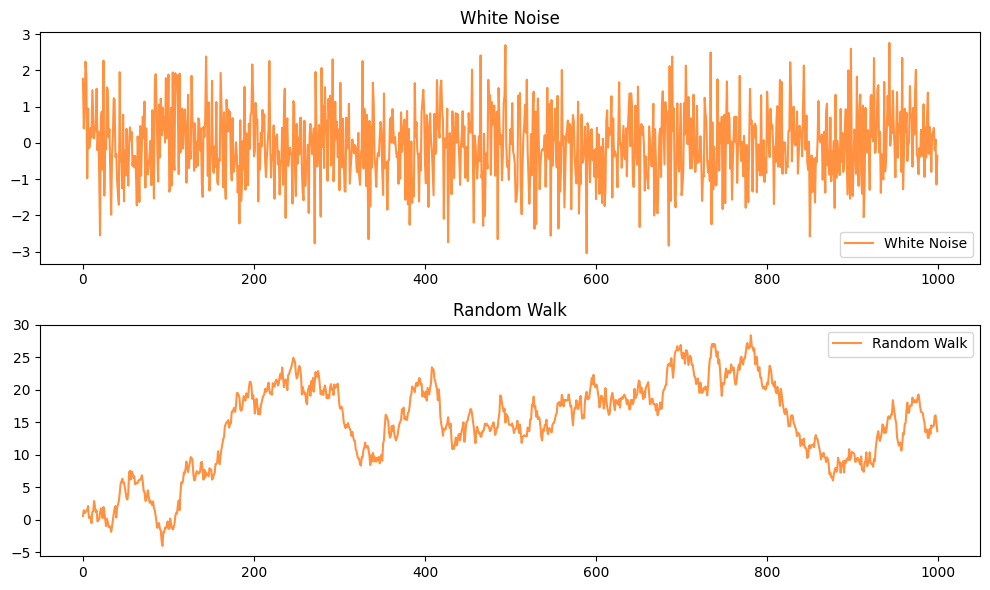


 Ljung-Box Test for White Noise
      lb_stat  lb_pvalue
10  14.025574   0.171828
**************************************************

 Ljung-Box Test for Random Walk
        lb_stat  lb_pvalue
10  8828.660312        0.0


In [22]:
# generating white noise and random walk for comparsion
np.random.seed(0)
n = 1000

# white noise
white_noise = np.random.normal(0,1,n)  # mean=0, var=1

# random walk
random_shocks = np.random.normal(0,1,n)
random_walk = np.cumsum(random_shocks)

# plotting the series
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(white_noise,label='White Noise',color='#FF9140')
plt.title('White Noise')
plt.legend()

plt.subplot(2,1,2)
plt.plot(random_walk,label='Random Walk',color='#FF9140')
plt.title('Random Walk')
plt.legend()

plt.tight_layout()
plt.show()


# Ljung-Box Test
print('\n Ljung-Box Test for White Noise')
print(acorr_ljungbox(white_noise,lags=[10],return_df=True))
print('*'*50)
print('\n Ljung-Box Test for Random Walk')
print(acorr_ljungbox(random_walk,lags=[10],return_df=True))

```
White noise = εt
Random walk = Yt = Yt-1 + εt
```
H0 = Their is no autocorrelation.

H1 = Their is autocorrelation.

if : p-value<0.05 -> reject H0 -> random  walk

else: p-value>0.05 -> accept H0 -> white noise

In [23]:
# Prepare the Reliance data
prices = df['Close'].dropna()

# First difference
prices_diff = prices.diff().dropna()

print("Original observations:", len(prices))
print("Differenced observations:", len(prices_diff))

prices_diff.head()

Original observations: 435
Differenced observations: 434


,Close
Date,
2025-01-02,20.374146
2025-01-03,9.270020
2025-01-06,-32.866333
2025-01-07,22.654297
2025-01-08,24.439087


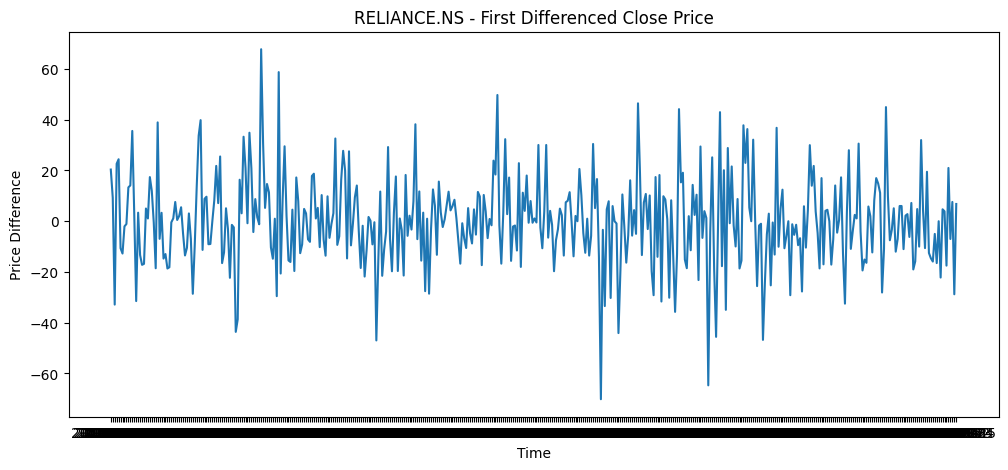

In [24]:
# Plot the differenced Reliance data
plt.figure(figsize=(12, 5))

plt.plot(prices_diff)

plt.title("RELIANCE.NS - First Differenced Close Price")
plt.xlabel("Time")
plt.ylabel("Price Difference")

plt.show()

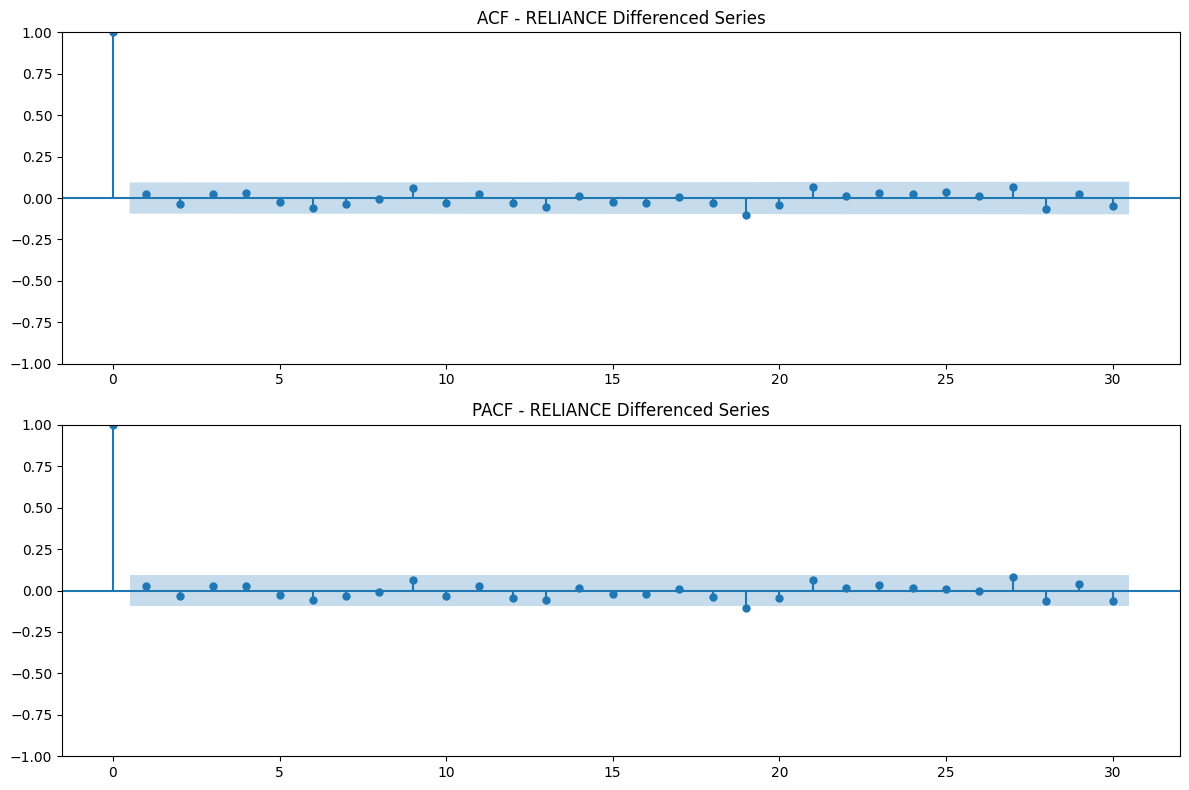

In [25]:
# Check ACF and PACF
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# month long lag
plot_acf(prices_diff, lags=30, ax=ax[0])
plot_pacf(prices_diff, lags=30, ax=ax[1], method='ywm')

ax[0].set_title("ACF - RELIANCE Differenced Series")
ax[1].set_title("PACF - RELIANCE Differenced Series")

plt.tight_layout()
plt.show()

# Time Series Forecasting Models

In [26]:
df.index = pd.to_datetime(df.index)

train_data, test_data = prices_diff[:-30], prices_diff[-30:]

### **AR(Auto Regressive) Model**

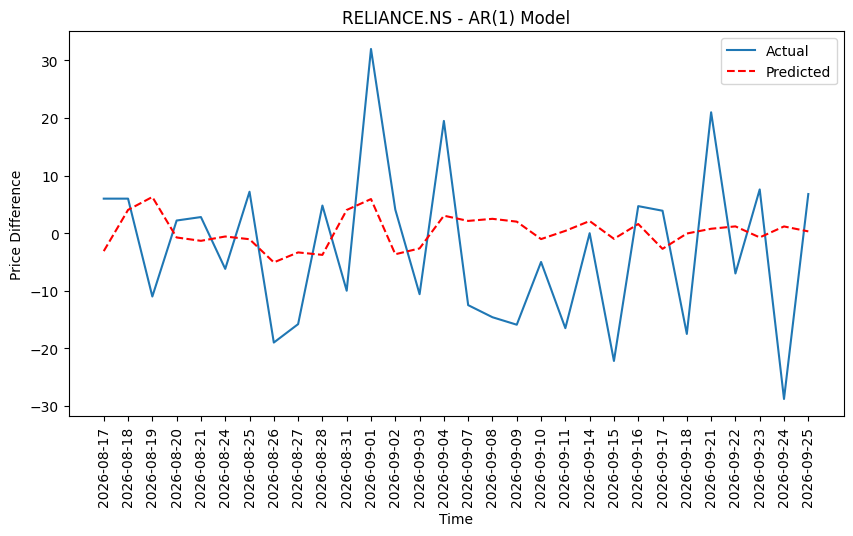


RMSE:  13.7


In [27]:
# fit the AR model to the training data
model = AutoReg(train_data.values, lags=30)
model_fit = model.fit()

# make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False)

# plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index,test_data, label='Actual')
plt.plot(test_data.index, predictions, label='Predicted',color='red', ls='--')
plt.title("RELIANCE.NS - AR(1) Model")
plt.xticks(rotation=90)
plt.xlabel("Time")
plt.ylabel("Price Difference")
plt.legend()
plt.show()

# calculate the mean squared error
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print("\nRMSE: ",rmse)

### **Moving Average**

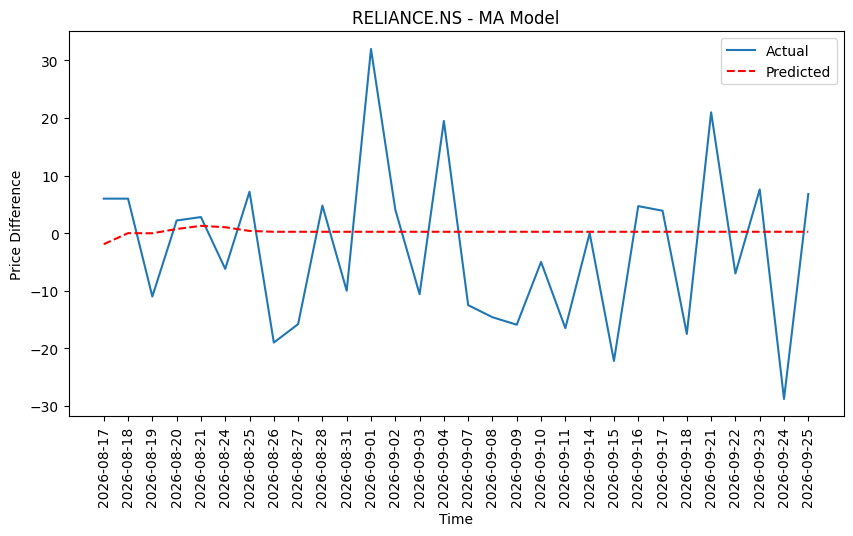


RMSE:  13.92


In [28]:
# fit the MA model to the training data
model = ARIMA(train_data.values, order=(0,0,7))
model_fit = model.fit()

# make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False)

# plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index,test_data, label='Actual')
plt.plot(test_data.index, predictions, label='Predicted',color='red', ls='--')
plt.title("RELIANCE.NS - MA Model")
plt.xticks(rotation=90)
plt.xlabel("Time")
plt.ylabel("Price Difference")
plt.legend()
plt.show()

# calculate the mean squared error
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print("\nRMSE: ",rmse)

### **ARMA Model**

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


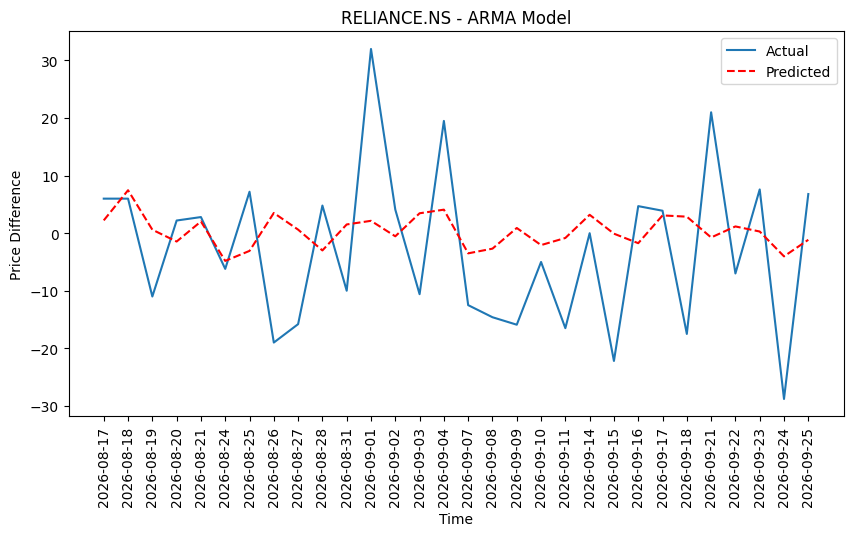


RMSE:  13.63


In [29]:
# fit the ARMA model to the training data
model = ARIMA(train_data.values, order=(10,0,10))
model_fit = model.fit()

# make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False)

# plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index,test_data, label='Actual')
plt.plot(test_data.index, predictions, label='Predicted',color='red', ls='--')
plt.title("RELIANCE.NS - ARMA Model")
plt.xticks(rotation=90)
plt.xlabel("Time")
plt.ylabel("Price Difference")
plt.legend()
plt.show()

# calculate the mean squared error
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print("\nRMSE: ",rmse)

### **ARIMA Model**

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


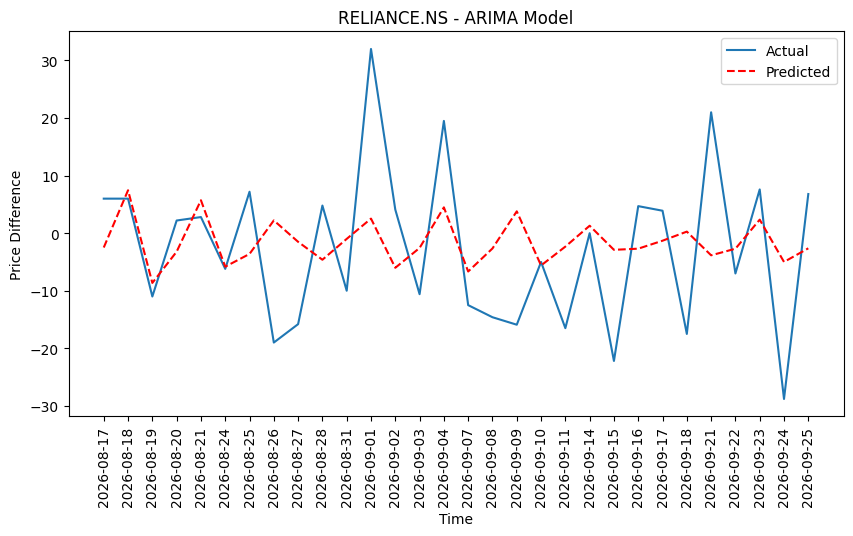


RMSE:  13.14


In [30]:
# fit the ARIMA model to the training data
model = ARIMA(train_data.values, order=(7,2,7))
model_fit = model.fit()

# make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False)

# plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index,test_data, label='Actual')
plt.plot(test_data.index, predictions, label='Predicted',color='red', ls='--')
plt.title("RELIANCE.NS - ARIMA Model")
plt.xticks(rotation=90)
plt.xlabel("Time")
plt.ylabel("Price Difference")
plt.legend()
plt.show()

# calculate the mean squared error
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print("\nRMSE: ",rmse)

### **SARIMA Model**

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


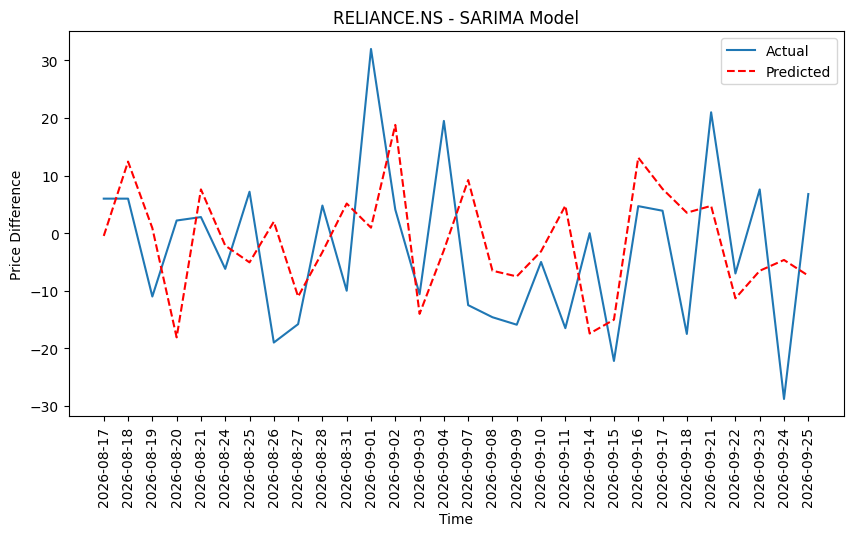


RMSE: 14.72


In [31]:
# fit the SARIMA model to the training data
model = SARIMAX(
    train_data.values,
    order=(7, 1, 7),
    seasonal_order=(1, 1, 1, 45))

model_fit = model.fit(disp=False)

# make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False
)

# plot the actual vs predicted values
plt.figure(figsize=(10, 5))

plt.plot(test_data.index,test_data,label='Actual')
plt.plot(test_data.index,predictions,label='Predicted',color='red',ls='--')

plt.title("RELIANCE.NS - SARIMA Model")
plt.xticks(rotation=90)
plt.xlabel("Time")
plt.ylabel("Price Difference")
plt.legend()
plt.show()

# calculate RMSE
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print("\nRMSE:", rmse)

In [32]:
tsla_data = yf.download('TSLA', start='2025-01-01')

df['TSLA_Close'] = tsla_data['Close']
df['RELIANCE_Close'] = df['Close'].shift()
df.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [33]:
# perform granger causality test
grangercausalitytests(df[['TSLA_Close', 'RELIANCE_Close']], maxlag=14)
print()

In [34]:
# differencing of both data, and train-test split
data = df[['TSLA_Close', 'RELIANCE_Close']].diff().dropna()
train_data, test_data = data[:-14], data[-14:]

# Reset indexes for statsmodels
train_model = train_data.reset_index(drop=True)
test_model = test_data.reset_index(drop=True)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


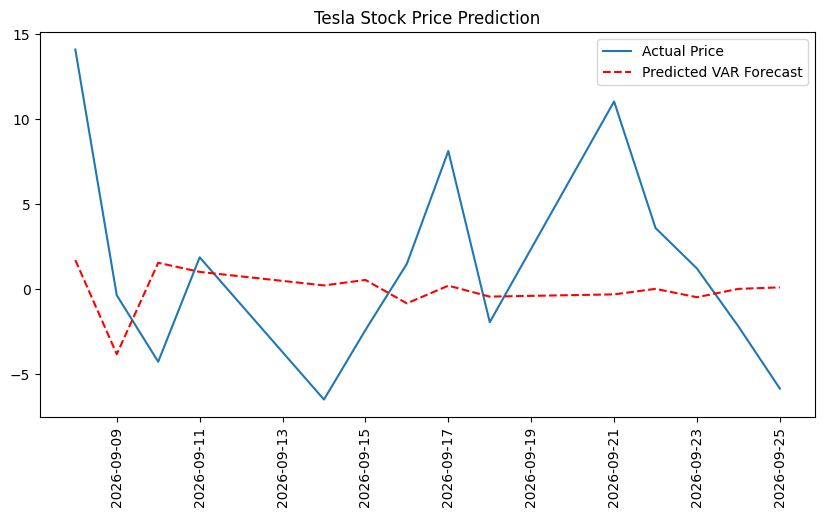


RMSE:  6.02


In [35]:
# VAR
model = VAR(train_data)
result = model.fit(maxlags=7)
predictions = result.forecast(train_data.values[-result.k_ar:], steps=len(test_data))

predictions = pd.DataFrame(predictions, index=test_data.index, columns=train_data.columns)
plt.figure(figsize=(10,5))
plt.plot(test_data.index,test_data['TSLA_Close'],label='Actual Price')
plt.plot(test_data.index,predictions['TSLA_Close'],label='Predicted VAR Forecast',color='red',ls='--')
plt.legend()
plt.xticks(rotation=90)
plt.title('Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])),2)
print('\nRMSE: ',rmse)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


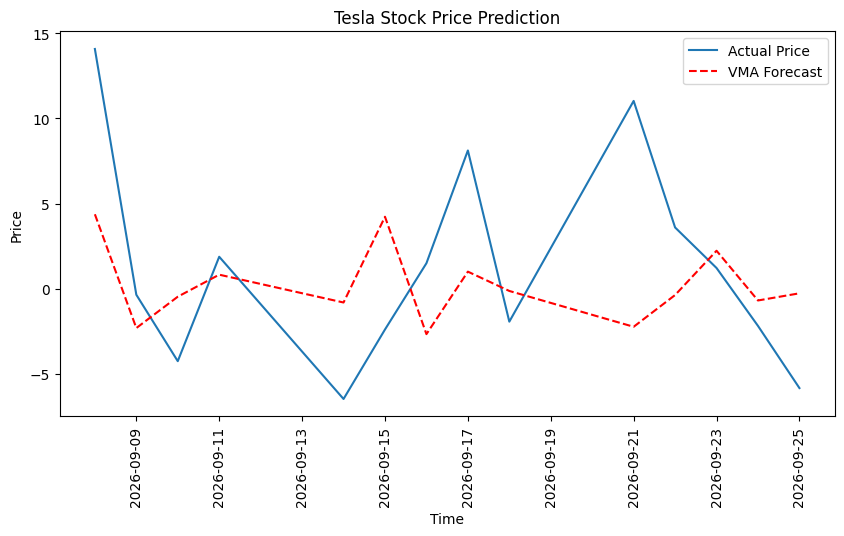


RMSE: 5.89


In [36]:
# Keep the original test dates for plotting
test_dates = test_data.index

# Reset indexes for statsmodels
train_model = train_data.reset_index(drop=True)
test_model = test_data.reset_index(drop=True)

# Fit VMA
model = VARMAX(train_model,order=(0, 14))
result = model.fit(disp=False)

# Make predictions
predictions = result.predict(start=len(train_model),end=len(train_model) + len(test_model) - 1,dynamic=False)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(test_dates,test_data['TSLA_Close'],label='Actual Price')
plt.plot(test_dates,predictions['TSLA_Close'],label='VMA Forecast',color='red',ls='--')
plt.title('Tesla Stock Price Prediction')
plt.xticks(rotation=90)
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# RMSE
rmse = round(np.sqrt(mean_squared_error(test_model['TSLA_Close'],predictions['TSLA_Close'])),2)
print("\nRMSE:", rmse)

/tmp/ipykernel_807/4106344523.py:2: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  model = VARMAX(train_model,order=(14, 14))
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


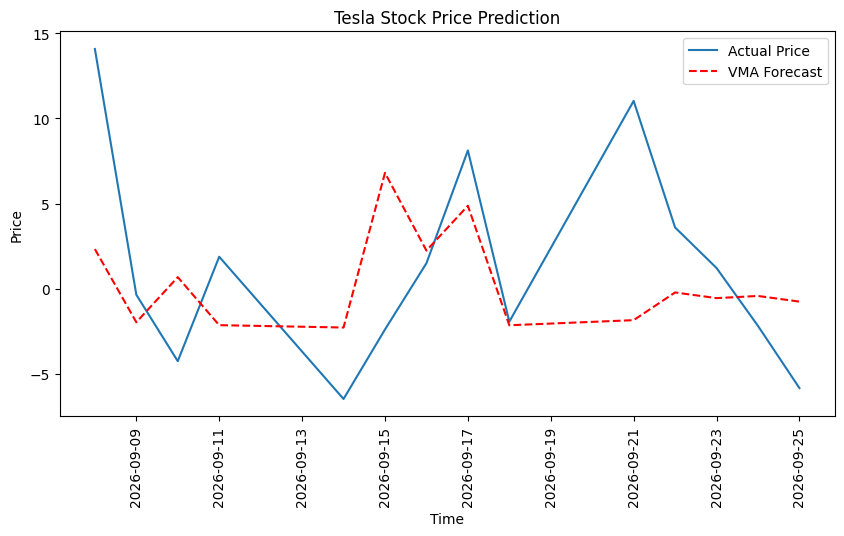


RMSE: 6.02


In [37]:
# Fit VARIMA
model = VARMAX(train_model,order=(14, 14))
result = model.fit(disp=False)

# Make predictions
predictions = result.predict(start=len(train_model),end=len(train_model) + len(test_model) - 1,dynamic=False)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(test_dates,test_data['TSLA_Close'],label='Actual Price')
plt.plot(test_dates,predictions['TSLA_Close'],label='VMA Forecast',color='red',ls='--')
plt.title('Tesla Stock Price Prediction')
plt.xticks(rotation=90)
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# RMSE
rmse = round(np.sqrt(mean_squared_error(test_model['TSLA_Close'],predictions['TSLA_Close'])),2)
print("\nRMSE:", rmse)

# Smoothing Techniques

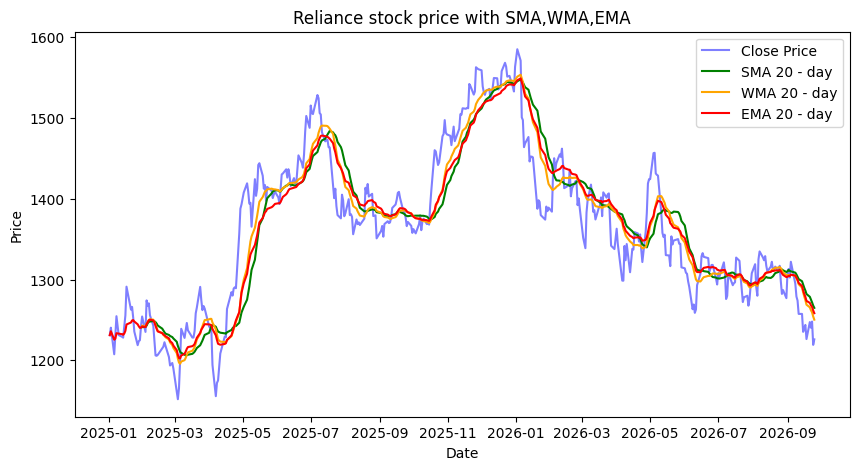

In [38]:
# Moving Average
window_size = 20
df['SMA'] = df['Close'].rolling(window_size).mean()

# calculate weighted moving average
weights = np.arange(1,window_size+1)
df['WMA'] = df['Close'].rolling(window_size).apply(lambda prices: np.dot(prices, weights)/weights.sum(),raw=True)

# calculate exponential moving average
df['EMA'] = df['Close'].ewm(span=window_size).mean()

# plotting
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Close Price',color='blue',alpha=0.5)
plt.plot(df['SMA'],label=f'SMA {window_size} - day',color='green')
plt.plot(df['WMA'],label=f'WMA {window_size} - day',color='orange')
plt.plot(df['EMA'],label=f'EMA {window_size} - day',color='red')

plt.title('Reliance stock price with SMA,WMA,EMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

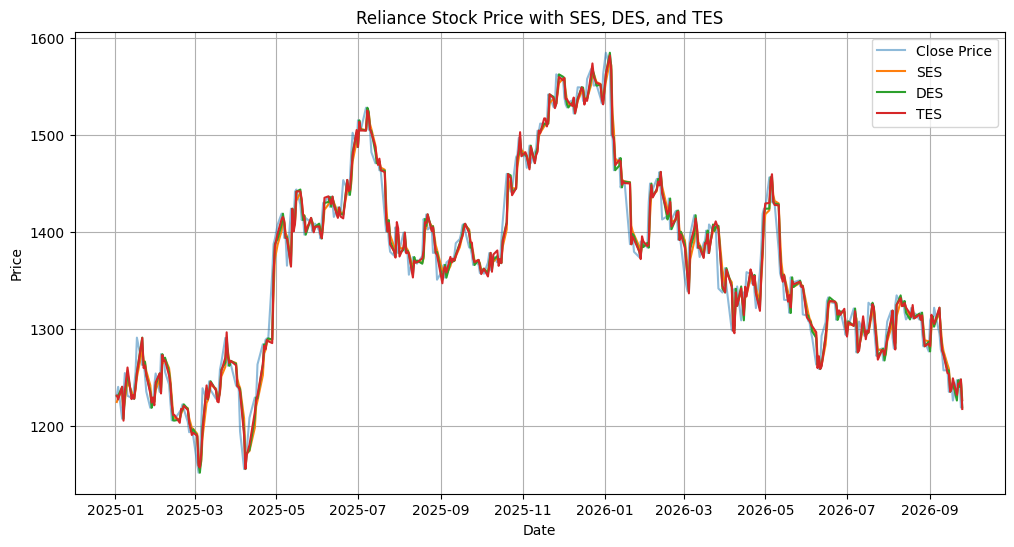

In [52]:
close_prices = df['Close'].astype(float)

# Single Exponential Smoothing
ses_model = SimpleExpSmoothing(close_prices,initialization_method='estimated').fit(optimized=False,smoothing_level=0.7)
df['SES'] = ses_model.fittedvalues

# Double Exponential Smoothing
# Holt's Linear Trend
des_model = ExponentialSmoothing(close_prices,trend='add',initialization_method='estimated').fit()
df['DES'] = des_model.fittedvalues

# Triple Exponential Smoothing
# Holt-Winters
tes_model = ExponentialSmoothing(close_prices,trend='add',seasonal='add',seasonal_periods=12,initialization_method='estimated').fit()
df['TES'] = tes_model.fittedvalues

# plorring
plt.figure(figsize=(12, 5))

plt.plot(df['Close'],label='Close Price',alpha=0.5)
plt.plot(df['SES'],label='SES')
plt.plot(df['DES'],label='DES')
plt.plot(df['TES'],label='TES')

plt.title('Reliance Stock Price with SES, DES, and TES')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

# ACF and PACF Test

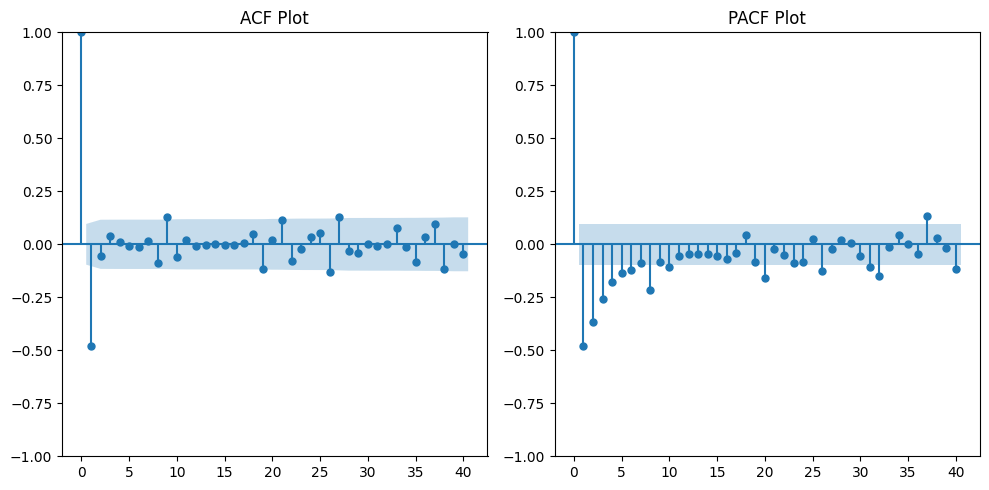

In [48]:
plt.figure(figsize=(10,5))

# ACF plot
plt.subplot(1,2,1)
plot_acf(df['Close'].diff().diff().dropna(),ax=plt.gca(),lags=40)
plt.title('ACF Plot')

# PACF plot
plt.subplot(1,2,2)
plot_pacf(df['Close'].diff().diff().dropna(),ax=plt.gca(),lags=40,method='ywm')
plt.title('PACF Plot')

plt.tight_layout()
plt.show()

In [56]:
# mean absolute error(MAE)
mae = mean_absolute_error(test_data,predictions)
print('MAE: ',mae)

# mean squared error(MSE)
mse = mean_squared_error(test_data,predictions)
print('MSE: ',mse)

# root mean squared error(MAE)
rmse = np.sqrt(mse)
print('RMSE: ',rmse)

# Mean Absolute Percentage Error (MAPE)
actual = np.array(test_data, dtype=float)
predicted = np.array(predictions, dtype=float)

mask = actual != 0
mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
print("MAPE:", mape, "%")

MAE:  8.801422924496297
MSE:  140.00843439982182
RMSE:  11.832515979275998
MAPE: 121.56095175381141 %
